# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Pyta Nur Chumairah
- **Email:** pytanur@gmail.com
- **ID Dicoding:** pytaaaaa26

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1:**

**"Siapa saja seller yang berhasil mempertahankan rata-rata skor review di atas 4.0 khusus untuk kategori produk dengan berat di atas 7kg selama periode tahun 2017 hingga 2018?"**

Keterangan:
- **Specific**: Fokus pada identifikasi seller dengan performa tinggi (skor > 4.0) yang menangani tantangan logistik khusus, yaitu produk berat (> 7kg).
- **Measurable**: Performa diukur secara kuantitatif melalui rata-rata skor review dan berat produk dalam kilogram yang tersedia di dataset.  
- **Action-Oriented**: Hasilnya dapat digunakan untuk memberikan apresiasi kepada seller tersebut atau menjadikan mereka mitra prioritas untuk kategori barang besar/berat.
- **Relevant**: Penanganan barang berat membutuhkan pengemasan dan logistik yang lebih baik; mengidentifikasi ahlinya sangat penting bagi operasional marketplace.  
- **Time-bound**: Dibatasi pada data transaksi sepanjang tahun 2017 hingga 2018.

**Pertanyaan 2:**

**"Berapa rata-rata selisih hari antara estimasi kedatangan dengan waktu pengiriman riil di wilayah Sao Paulo selama Semester 1 2018, dan kategori produk apa yang paling sering mengalami keterlambatan?"**

- **Specific**: Menghitung selisih waktu pengiriman khusus untuk pelanggan di wilayah Sao Paulo.  
- **Measurable**: Diukur dengan menghitung rata-rata perbedaan antara kolom order_estimated_delivery_date dan order_delivered_customer_date.  
- **Action-Oriented**: Memungkinkan tim logistik melakukan optimasi rute atau mengevaluasi mitra pengiriman di wilayah Sao Paulo untuk kategori produk tertentu yang bermasalah.  
- **Relevant**: Ketepatan waktu pengiriman adalah faktor kunci kepuasan pelanggan dalam e-commerce.  
- **Time-bound**: Dibatasi pada periode Januari-Juni tahun 2018.

**Pertanyaan 3:**

**"Kategori produk mana yang menghasilkan total revenue tertinggi namun memiliki rata-rata skor review di bawah 4.0 pada periode Januari hingga Juni 2018?"**

- **Specific**: Mencari ketimpangan antara pendapatan tinggi dan kepuasan rendah pada kategori produk tertentu.  
- **Measurable**: Menggunakan metrik total harga (price) untuk revenue dan skor review (review_score) untuk kepuasan.  
- **Action-Oriented**: Memberikan arahan bagi manajemen untuk menginvestigasi kualitas produk atau supplier di kategori tersebut guna mencegah churn pelanggan di masa depan.  
- **Relevant**: Produk yang laris tapi buruk kualitasnya dapat merusak reputasi jangka panjang platform Olist.  
- **Time-bound**: Dibatasi pada periode Januari-Juni tahun 2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load customers_df, order_items_df, order_payments_df, order_reviews_df, orders_df, products_df, product_category_name_translation_df

In [3]:
customers_df = pd.read_csv('customers_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
product_category_name_translation_df = pd.read_csv('product_category_name_translation.csv')
sellers_df = pd.read_csv('sellers_dataset.csv')

**Insight:**

Dari dataset yang tersedia, tidak semua tabel akan digunakan untuk mendapatkan jawaban dari 3 pertanyaan bisnis yang telah ditentukan.
- Pertanyaan pertama membutuhkan tabel: 'orders_df', 'order_items_df', 'products_df', 'order_reviews_df', dan 'sellers_df'.
- Pertanyaan kedua membutuhkan tabel: 'orders_df', ''order_items_df'', 'products_df', dan 'customers_df'.
- Pertanyaan ketiga membutuhkan tabel: 'orders_df', 'order_items_df','product_df', dan 'order_reviews_df'.
- 'product_category_name_translation_df' akan digunakan untuk mendapatkan nama-nama produk dalam bahasa Inggris.

### Assessing Data

#### Identifying missing value and data type problem

In [4]:
print("\n customers_df missing value: ")
print(customers_df.isnull().sum())
print("\n order_items_df missing value: ")
print(order_items_df.isnull().sum())
print("\n order_payments_df missing value: ")
print(order_payments_df.isnull().sum())


 customers_df missing value: 
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 order_items_df missing value: 
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 order_payments_df missing value: 
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [5]:
print("\n order_reviews_df missing value: ")
print(order_reviews_df.isnull().sum())
print("\n orders_df missing value: ")
print(orders_df.isnull().sum())
print("\n products_df missing value: ")
print(products_df.isnull().sum())
print("\n sellers_df missing value: ")
print(sellers_df.isnull().sum())


 order_reviews_df missing value: 
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

 orders_df missing value: 
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 products_df missing value: 
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

 sellers_df missing value:

#### Identifying duplicate data problem

In [6]:
print("\n Data duplicates in customers_df: ", customers_df.duplicated().sum())
print("\n Data duplicates in order_items_df: ", order_items_df.duplicated().sum())
print("\n Data duplicates in order_payments_df: ", order_payments_df.duplicated().sum())
print("\n Data duplicates in order_reviews_df: ", order_reviews_df.duplicated().sum())
print("\n Data duplicates in orders_df: ", orders_df.duplicated().sum())
print("\n Data duplicates in products_df: ", products_df.duplicated().sum())
print("\n Data duplicates in sellers_df: ", sellers_df.duplicated().sum())


 Data duplicates in customers_df:  0

 Data duplicates in order_items_df:  0

 Data duplicates in order_payments_df:  0

 Data duplicates in order_reviews_df:  0

 Data duplicates in orders_df:  0

 Data duplicates in products_df:  0

 Data duplicates in sellers_df:  0


#### Identifying the formatting of the value

In [7]:
print("\n customers_df head: ")
customers_df.sample(5)


 customers_df head: 


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
90533,518ddb65d7023b1e0ca0b66f27533d26,6fe279814d16772b218b116cd015e1c4,89035,blumenau,SC
72621,6d54b2b3ee38a0af088d05f349aa9afc,b08a631ea9c462557bc15f59b72790c0,88309,itajai,SC
93670,dca4146c656edd385afbab8f8e1462b1,f80242bdb5b97002ad7a221092503c3d,99040,passo fundo,RS
55772,36e70d326ab414aaf5be6ba0eab5bfde,4fbbe3e555c12c6fb7184b3e2d04fb49,30575,belo horizonte,MG
97477,fef16d4748e573e3e48809c20be99bb3,04aedd3815fd63024eeb9d426a857d55,25260,duque de caxias,RJ


In [8]:
print("\n order_items_df head: ")
order_items_df.sample(5)


 order_items_df head: 


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
97749,ddc3d480190a889acc51fb21d634c044,1,5af8eddd880e2463740be6828d2b51dd,4a3ca9315b744ce9f8e9374361493884,13-09-17 12:45,259.90,13.32
8400,132947cc0a6620350693052f3548070f,1,e5e4c79bce72fc7476860916c1a9dd18,e5f9e61ceb5f523cc966e0f34095032f,07-03-18 02:49,449.00,26.01
5091,0b8b249ad3dde632e5f162167e0b9f07,1,814db92f0cda8c71fa27f4b022cea56f,827f8f69dfa529c561901c4f2e0f332f,04-08-17 18:50,25.90,15.79
31192,46c0b3ab3b1d05b0f8af19f0100a33c4,1,bb50f2e236e5eea0100680137654686c,f7ba60f8c3f99e7ee4042fdef03b70c4,21-08-18 18:49,330.00,39.22
31850,48355743de20d2abaed10440296594e5,1,013b5dd7d319685753e2c12292975615,099095b050cfe8eb1ddff5317587e96e,19-04-18 20:51,265.99,96.82


In [9]:
print("\n order_payments_df head: ")
order_payments_df.sample(5)


 order_payments_df head: 


,order_id,payment_sequential,payment_type,payment_installments,payment_value
752,8ca5bdac5ebe8f2d6fc9171d5ebc906a,3,voucher,1,15.00
73452,5f766dfc65eff86be5b3015dbce0e2c6,1,credit_card,4,112.25
23729,fdda37c607e545cc35b20ab1eb1a057a,1,credit_card,1,62.22
45271,c647254c19cb14894d4cf37d3d8e450b,1,credit_card,1,47.44
8753,37a4ce5cc129f57f3c0d75ea0930f420,1,credit_card,5,53.75


In [10]:
print("\n order_reviews_df head: ")
order_reviews_df.sample(5)


 order_reviews_df head: 


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
47461,a49e16a5cdf1e2320bf8ac81deef225f,ada32a7778f9bfa7e805008da5f02d50,1,NaN,Ja mandei o cancelamento e pedido de devolução...,15-04-17 00:00,16-04-17 20:30
42079,14bb32cd7ad48a9fe9a4bd8fae36069c,8db0f0edb7e7b18d50df712eb5b1a1b4,5,NaN,NaN,06-12-17 00:00,09-12-17 02:39
82055,182338537db3f6f2f382714f40f66265,adaf9c2200eccede886e041415e89df1,1,NaN,Não era o que eu esperava,15-10-17 01:00,15-10-17 09:49
1124,da6919696d33832d2280b7bca195b94b,a923f706eeccdbdf02d5db99c8550c8d,5,NaN,Excelente produto!!,21-03-18 00:00,23-03-18 00:53
79757,de6a425e8318869280582fbf41a87fee,a5803df1ae0cd16429a109eb0514ddca,5,NaN,NaN,31-01-18 00:00,20-02-18 17:18


In [11]:
print("\n orders_df head: ")
orders_df.head()


 orders_df head: 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-17 10:56,02-10-17 11:07,04-10-17 19:55,10-10-17 21:25,18-10-17 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-18 20:41,26-07-18 03:24,26-07-18 14:31,07-08-18 15:27,13-08-18 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-18 08:38,08-08-18 08:55,08-08-18 13:50,17-08-18 18:06,04-09-18 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-17 19:28,18-11-17 19:45,22-11-17 13:39,02-12-17 00:28,15-12-17 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-18 21:18,13-02-18 22:20,14-02-18 19:46,16-02-18 18:17,26-02-18 00:00


In [12]:
print("\n products_df head: ")
products_df.head()


 products_df head: 


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [13]:
print("\n product_category_name_translation_df head: ")
product_category_name_translation_df.sample(5)


 product_category_name_translation_df head: 


,product_category_name,product_category_name_english
26,moveis_cozinha_area_de_servico_jantar_e_jardim,kitchen_dining_laundry_garden_furniture
33,eletrodomesticos,home_appliances
46,artes,art
61,musica,music
42,moveis_sala,furniture_living_room


In [14]:
print("\n sellers_df head: ")
sellers_df.sample(5)


 sellers_df head: 


,seller_id,seller_zip_code_prefix,seller_city,seller_state
2098,1fa2d3def6adfa70e58c276bb64fe5bb,4106,sao paulo,SP
2941,2d2322d842118867781fc737e96d59a1,5879,sao paulo,SP
465,dc64d75cc406bb0697be983831430e60,31560,belo horizonte,MG
2769,0ec28cec4046a4a199b6de9b4c891d97,74110,goiania,GO
205,3db66a856d18a9cba7c9241fc5221c50,35430,ponte nova,MG


**Steps to Take:**
- Mengubah tipe data pada kolom tanggal di 'orders_df' dan 'order_reviews_df' menjadi datetime.
- Menghapus baris data pesanan yang tidak memiliki tanggal pengiriman pada tabel 'orders_df'.
- Menghapus baris data produk yang tidak memiliki informasi berat pada tabel 'products_df' karena jumlahnya yang sangat sedikit.
- Mengisi missing values pada kolom 'product_category_name' di tabel 'products_df' dengan 'others'
- Mengganti nama kategori produk dari bahasa Portugis ke bahasa Inggris

**Insight:**
- Terdapat fitur kunci yang menyimpan informasi waktu di tabel 'orders_df' dan 'order_reviews_df' bertipe object dan bukan datetime.
- Terdapat missing value pada kolom tanggal pengiriman pada tabel 'orders_df'
- Ditemukan sejumlah produk pada tabel 'products_df' yang tidak memiliki nama kategori.
- Nama kategori produk saat ini masih dalam bahasa Portugis.
- Tidak ditemukan baris data yang duplikat.

### Cleaning Data

#### Fixing data type problem

In [15]:
# order_reviews_df
datetime_columns_reviews = ['review_creation_date', 'review_answer_timestamp']
for column in datetime_columns_reviews:
    order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')

# orders_df
datetime_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')

/tmp/ipykernel_9070/801796690.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')
/tmp/ipykernel_9070/801796690.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')
/tmp/ipykernel_9070/801796690.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')
/tmp/ipykernel_9070/801796690.py:15: UserWarning: Could not infer format, so each element wi

#### Fixing missing value problem

Drop the data with missing values in the 'order_delivered_carrier_date' column in the 'orders_df' table

In [16]:
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

Replace the data with unknown category with 'Others' in the 'product_category_name' column in the 'products_df' table

In [17]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('Others')

Drop the data with missing values in the 'product_weight_g' column in the 'products_df' table

In [18]:
products_df.dropna(subset=['product_weight_g'], inplace=True)

Mengecek kembali missing value

In [19]:
print("\n customers_df missing value: ")
print(customers_df.isnull().sum())
print("\n order_items_df missing value: ")
print(order_items_df.isnull().sum())
print("\n order_payments_df missing value: ")
print(order_payments_df.isnull().sum())
print("\n order_reviews_df missing value: ")
print(order_reviews_df.isnull().sum())
print("\n orders_df missing value: ")
print(orders_df.isnull().sum())
print("\n products_df missing value: ")
print(products_df.isnull().sum())


 customers_df missing value: 
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 order_items_df missing value: 
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 order_payments_df missing value: 
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 order_reviews_df missing value: 
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

 orders_df missing value: 
order_id                          0
customer_id                       0
order_status               

#### Fixing language problem

In [20]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [21]:
# Menggunakan left join untuk mengambil bahasa inggris dari kategori produk
products_df = pd.merge(
    products_df,
    product_category_name_translation_df,
    on='product_category_name',
    how='left'
)

# Menghapus kolom kategori produk dengan bahasa Portugis
products_df.drop('product_category_name', axis=1, inplace=True)

# Mengganti nama kolom kategori produk dengan bahasa Inggris
products_df.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)

# Memastikan kolom others tetap ada
products_df['product_category_name'] = products_df['product_category_name'].fillna('others')

In [22]:
products_df.head()

,product_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [23]:
products_df['product_category_name']

,product_category_name
0,perfumery
1,art
2,sports_leisure
3,baby
4,housewares
...,...
32944,furniture_decor
32945,construction_tools_lights
32946,bed_bath_table
32947,computers_accessories


**Insight:**
- Semua kolom dengan jenis informasi waktu berhasil diubah menjadi tipe datetime.
- Mengatasi missing value dengan drop baris pada kolom 'order_delivered_carrier_date' pada tabel 'orders_df' dan kolom 'product_weight_g' pada tabel 'products_df'.
- Mengatasi missing value pada kolom 'product_category_name' dengan mengubah nilainya menjadi 'Others'.
- Berhasil mentranslasi kategori produk dari bahasa Portugis ke bahasa Inggris.
- Tidak ditemukan data duplikat, sehingga tidak perlu ditindaki.

## Exploratory Data Analysis (EDA)

### Explore Question 1

In [24]:
# Menggabungkan tabel yang dibutuhkan
q1_df = order_items_df.merge(products_df, on='product_id', how='left')
q1_df = q1_df.merge(order_reviews_df, on='order_id', how='left')
q1_df = q1_df.merge(sellers_df[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

#### Explore products weight distribution

In [25]:
# Explore products weight distribution
print("Distribusi Berat Produk (Gram):")
display(q1_df['product_weight_g'].describe())

Distribusi Berat Produk (Gram):


,product_weight_g
count,113296.000000
mean,2091.915037
std,3749.804597
min,0.000000
25%,300.000000
50%,700.000000
75%,1800.000000
max,40425.000000


#### Explore review score comparison

In [26]:
# Membuat kategori berat: Light (<3kg), Medium (3-7kg), Heavy (>7kg)
bins = [0, 3000, 7000, float('inf')]
labels = ['Light (<3kg)', 'Medium (3-7kg)', 'Heavy (>7kg)']

q1_df['weight_category'] = pd.cut(q1_df['product_weight_g'], bins=bins, labels=labels)

print("\nPerbandingan Rata-rata Skor Review berdasarkan 3 Kategori:")
review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()
display(review_comparison)


Perbandingan Rata-rata Skor Review berdasarkan 3 Kategori:


/tmp/ipykernel_9070/2087048991.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()


,weight_category,review_score
0,Light (<3kg),4.043551
1,Medium (3-7kg),4.068172
2,Heavy (>7kg),3.885142


#### Explore high-performing sellers

In [27]:
# Filter hanya barang berat
heavy_items = q1_df[q1_df['weight_category'] == 'Heavy (>7kg)']

# Agregasi performa seller
seller_performance = heavy_items.groupby(['seller_id', 'seller_zip_code_prefix']).agg(
    avg_review_score=('review_score', 'mean'),
    total_heavy_orders=('order_id', 'nunique'),
).reset_index()

# Filter skor > 4.0 dan urutkan dari pesanan terbanyak
high_performing_sellers = seller_performance[seller_performance['avg_review_score'] > 4.0].sort_values(by='total_heavy_orders', ascending=False)
print("\nTop High-Performing Sellers untuk Barang Berat:")
display(high_performing_sellers.head(10))


Top High-Performing Sellers untuk Barang Berat:


,seller_id,seller_zip_code_prefix,avg_review_score,total_heavy_orders
190,3d871de0142ce09b7081e2b9d1733cb1,13232,4.140351,279
169,37be5a7c751166fbc5f8ccba4119e043,4248,4.375000,150
470,a1043bafd471dff536d0c462352beb48,37175,4.214815,129
88,1a3df491d1c4f1589fc2b934ada68bf2,89224,4.180451,123
76,17a053fcb14bd219540cbde0df490be0,13843,4.198630,123
254,53e4c6e0f4312d4d2107a8c9cddf45cd,13920,4.108696,122
396,8581055ce74af1daba164fdbd55a40de,7112,4.330435,112
638,d94a40fd42351c259927028d163af842,37443,4.102804,100
607,ce7d1888639e6fb06b2749cbfdac1ff7,37443,4.107143,78
389,834f3294fba9f932f56edc879193f925,14808,4.545455,66


### Explore Question 2

In [28]:
# Menggabungkan tabel yang dibutuhkan
q2_df = orders_df.merge(customers_df, on='customer_id', how='left')
q2_df = q2_df.merge(order_items_df, on='order_id', how='left')
q2_df = q2_df.merge(products_df, on='product_id', how='left')

q2_df = q2_df[
    (q2_df['customer_city'] == 'sao paulo') &
    (q2_df['order_purchase_timestamp'] >= '2018-01-01') &
    (q2_df['order_purchase_timestamp'] <= '2018-06-30')
].copy()

q2_df['order_purchase_timestamp'] = pd.to_datetime(q2_df['order_purchase_timestamp'])
q2_df['order_delivered_customer_date'] = pd.to_datetime(q2_df['order_delivered_customer_date'])
q2_df['order_estimated_delivery_date'] = pd.to_datetime(q2_df['order_estimated_delivery_date'])


q2_df['delivery_margin_days'] = (q2_df['order_delivered_customer_date'] - q2_df['order_estimated_delivery_date']).dt.days

q2_df['pure_delay_days'] = q2_df['delivery_margin_days'].clip(lower=0)

q2_df['purchase_month'] = q2_df['order_purchase_timestamp'].dt.month

#### Explore logistic monthly trend

In [29]:
monthly_trend = q2_df.groupby('purchase_month')[['pure_delay_days', 'delivery_margin_days']].mean().reset_index()

# Analisis Kategori
category_analysis = q2_df.groupby('product_category_name').agg(
    avg_delay_days=('pure_delay_days', 'mean'),
    total_order_cases=('order_id', 'nunique')
).reset_index()

top_10_filtered = category_analysis[category_analysis['total_order_cases'] >= 30] \
    .sort_values(by='avg_delay_days', ascending=False) \
    .head(10)

print("Data Preparation Selesai. Kolom 'purchase_month' berhasil dibuat.")
display(monthly_trend.head())

Data Preparation Selesai. Kolom 'purchase_month' berhasil dibuat.


,purchase_month,pure_delay_days,delivery_margin_days
0,1,31.505495,-24.781136
1,2,33.294013,-32.124218
2,3,28.865554,-24.779438
3,4,34.794409,-16.201082
4,5,39.219015,7.665535


#### Explore problem product categories

In [30]:
# Mengambil pesanan yang terlambat saja
category_analysis = q2_df.groupby('product_category_name').agg(
    avg_delay_days=('pure_delay_days', 'mean'),
    total_order_cases=('order_id', 'nunique') # Total semua pesanan di kategori tersebut
).reset_index()

problem_categories = category_analysis[category_analysis['total_order_cases'] >= 30] \
    .sort_values(by='avg_delay_days', ascending=False)

print("\nTop 10 Kategori Produk dengan Rata-rata Keterlambatan Terburuk (Min. 30 Pesanan):")
display(problem_categories.head(10))


Top 10 Kategori Produk dengan Rata-rata Keterlambatan Terburuk (Min. 30 Pesanan):


,product_category_name,avg_delay_days,total_order_cases
14,consoles_games,43.416667,35
50,luggage_accessories,43.092593,49
55,others,41.743243,69
34,food,41.295455,36
37,furniture_decor,40.919622,334
15,construction_tools_construction,39.310345,68
6,bed_bath_table,39.300406,601
65,telephony,37.150943,202
66,toys,35.610811,173
67,watches_gifts,35.421365,313


#### Explore delay ratio

In [31]:
q2_df['delivery_status'] = np.where(q2_df['pure_delay_days'] > 0, 'Delayed', 'On Time / Early')
delay_ratio = q2_df['delivery_status'].value_counts(normalize=True) * 100
print("\nRasio Keterlambatan Pengiriman (%):")
display(delay_ratio)


Rasio Keterlambatan Pengiriman (%):


,proportion
delivery_status,
On Time / Early,63.420108
Delayed,36.579892


### Explore Question 3

In [32]:
# Menggabungkan tabel yang dibutuhkan
q3_df = orders_df.merge(order_items_df, on='order_id', how='left')
q3_df = q3_df.merge(products_df, on='product_id', how='left')
q3_df = q3_df.merge(order_reviews_df, on='order_id', how='left')

q3_df['order_purchase_timestamp'] = pd.to_datetime(q3_df['order_purchase_timestamp'])

q3_df = q3_df[
    (q3_df['order_purchase_timestamp'] >= '2018-01-01') &
    (q3_df['order_purchase_timestamp'] < '2018-07-01')
]

#### Explore revenue vs rating Chart

In [33]:
category_metrics = q3_df.groupby('product_category_name').agg(
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean')
).reset_index()

print("Total Revenue dan Rata-rata Skor Review per Kategori:")
display(category_metrics.head(10))

Total Revenue dan Rata-rata Skor Review per Kategori:


,product_category_name,total_revenue,avg_review_score
0,agro_industry_and_commerce,25649.70,4.322581
1,air_conditioning,15685.08,3.919643
2,art,9953.18,3.972477
3,arts_and_craftmanship,148.79,4.500000
4,audio,25128.65,3.773438
5,auto,214577.04,4.084643
6,baby,179832.14,3.974271
7,bed_bath_table,361889.26,3.852994
8,books_general_interest,19516.62,4.514151
9,books_imported,2138.18,4.750000


#### Explore volume vs value

In [34]:
# Menghitung metrik jumlah item yang terjual per kategori
volume_df = q3_df.groupby('product_category_name').agg(
    total_volume=('order_item_id', 'count')
).reset_index()

category_performance = category_metrics.merge(volume_df, on='product_category_name', how='left')

# Filter kategori dengan volume pesanan lebih dari 30 dan skor review di bawah 4.0
threshold_volume = 30
threshold_rating = 4.0

problematic_cats = category_performance[
    (category_performance['avg_review_score'] < threshold_rating) &
    (category_performance['total_volume'] >= threshold_volume)
].sort_values(by='total_revenue', ascending=False)

print("Kategori Produk Paling Bermasalah (Skor < 4.0) Berdasarkan Total Revenue:")
display(problematic_cats.head(10))

Kategori Produk Paling Bermasalah (Skor < 4.0) Berdasarkan Total Revenue:


,product_category_name,total_revenue,avg_review_score,total_volume
7,bed_bath_table,361889.26,3.852994,3924
15,computers_accessories,351427.14,3.854173,3287
39,furniture_decor,256018.86,3.924019,2796
6,baby,179832.14,3.974271,1174
57,office_furniture,104512.50,3.426647,672
68,telephony,95651.86,3.902065,1513
17,construction_tools_construction,75168.41,3.991111,452
58,others,51568.69,3.783550,464
48,home_construction,40114.83,3.993769,322
14,computers,28226.93,3.941176,34


#### Explore review analysis

In [35]:
# Mengambil nama kategori yang ada di peringkat 1 paling bermasalah
top_1_category = problematic_cats.iloc[0]['product_category_name']

# Memfilter data asli khusus untuk kategori tersebut
top_cat_reviews = q3_df[q3_df['product_category_name'] == top_1_category]

# Menghitung jumlah masing-masing skor review
review_distribution = top_cat_reviews['review_score'].value_counts().reset_index()
review_distribution.columns = ['review_score', 'jumlah_review']
review_distribution = review_distribution.sort_values(by='review_score', ascending=False).reset_index(drop=True)

print(f"Distribusi Skor Review pada Kategori: {top_1_category}")
display(review_distribution)

Distribusi Skor Review pada Kategori: bed_bath_table


,review_score,jumlah_review
0,5.0,2002
1,4.0,709
2,3.0,397
3,2.0,172
4,1.0,611


## Visualization & Explanatory Analysis

### Pertanyaan 1:

Untuk visualisasi pertanyaan pertama, saya mempertimbangkan kembali untuk menghapus visualisasi pertama pada notebook sebelumnya karena tidak memberikan dampak yang besar untuk menjawab pertanyaan pertama dan informasinya telah dimuat pada visualisasi ke-2.

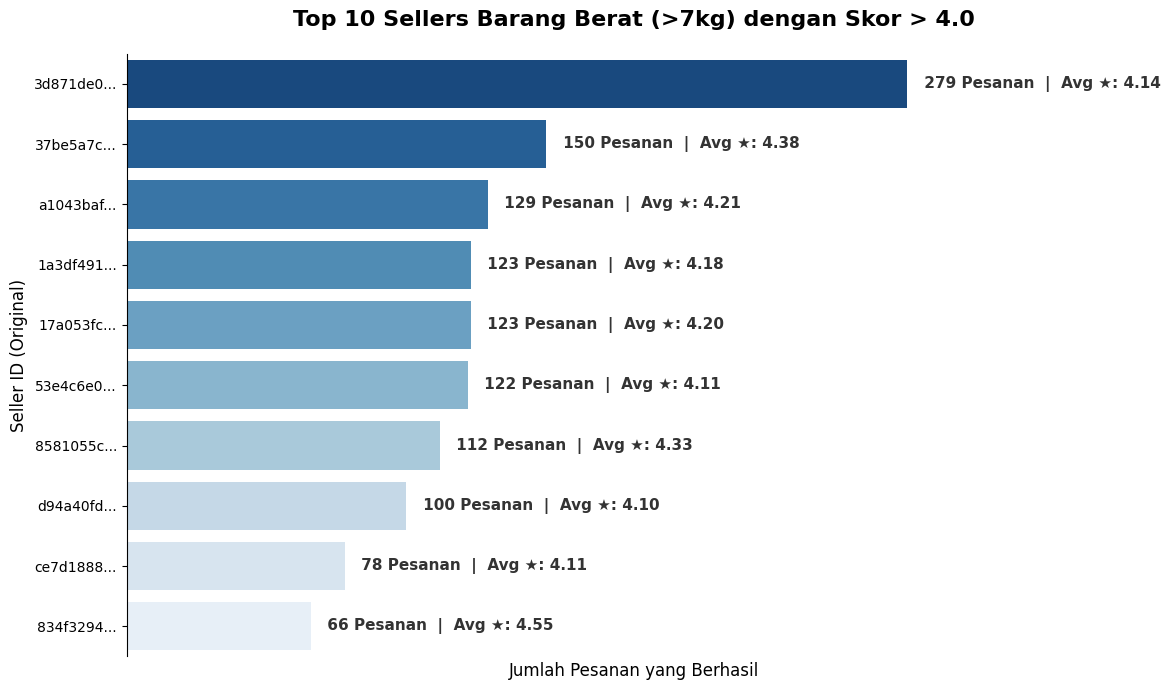

In [36]:
top_10_sellers = high_performing_sellers.head(10).copy()
top_10_sellers['seller_id_short'] = top_10_sellers['seller_id'].str[:8] + "..."

fig, ax = plt.subplots(figsize=(12, 7))

"""Visualisasi menggunakan seller_id asli berupa string ID panjang
karena dataset tidak menyediakan nama unik untuk setiap seller.
Oleh karena itu saya menggunakan 8 karakter pertama seller_id"""
sns.barplot(
    x='total_heavy_orders',
    y='seller_id_short',
    data=top_10_sellers,
    palette='Blues_r',
    hue='seller_id_short',
    legend=False,
    ax=ax
)

ax.set_title('Top 10 Sellers Barang Berat (>7kg) dengan Skor > 4.0', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Jumlah Pesanan yang Berhasil', fontsize=12)
ax.set_ylabel('Seller ID (Original)', fontsize=12)

# Menghilangkan sumbu X karena angka sudah ada di label bar
ax.set_xticks([])
sns.despine(bottom=True, left=False)

# Memberikan label angka di samping bar
for i, p in enumerate(ax.patches):
    count = int(p.get_width())
    avg_score = top_10_sellers['avg_review_score'].iloc[i]

    ax.annotate(
        f' {count} Pesanan  |  Avg ★: {avg_score:.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

ax.set_xlim(0, top_10_sellers['total_heavy_orders'].max() * 1.3)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

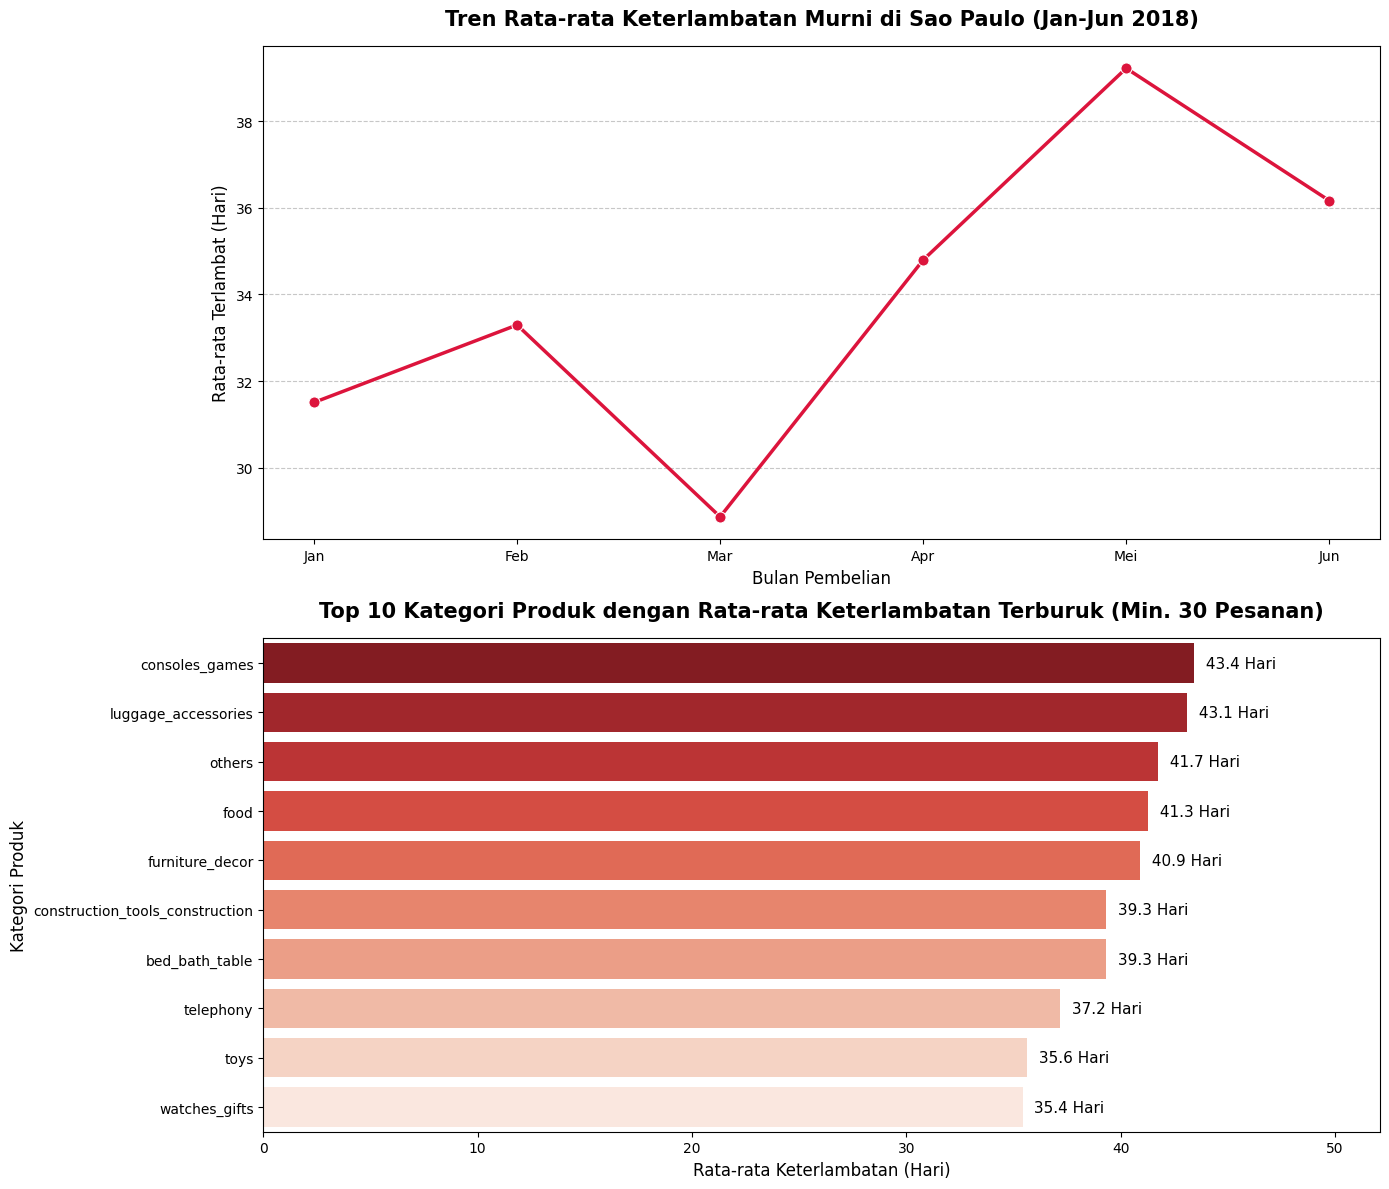

In [37]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Visualisasi 1: Tren Bulanan
sns.lineplot(
    x='purchase_month',
    y='pure_delay_days',
    data=monthly_trend,
    marker='o',
    color='crimson',
    linewidth=2.5,
    markersize=8,
    ax=ax[0]
)
ax[0].set_title('Tren Rata-rata Keterlambatan Murni di Sao Paulo (Jan-Jun 2018)', fontsize=15, pad=15, fontweight='bold')
ax[0].set_xlabel('Bulan Pembelian', fontsize=12)
ax[0].set_ylabel('Rata-rata Terlambat (Hari)', fontsize=12)
ax[0].set_xticks(range(1, 7))
ax[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun'])
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Visualisasi 2: Kategori Terburuk
sns.barplot(
    x='avg_delay_days',
    y='product_category_name',
    data=top_10_filtered,
    palette='Reds_r',
    hue='product_category_name',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Top 10 Kategori Produk dengan Rata-rata Keterlambatan Terburuk (Min. 30 Pesanan)', fontsize=15, pad=15, fontweight='bold')
ax[1].set_xlabel('Rata-rata Keterlambatan (Hari)', fontsize=12)
ax[1].set_ylabel('Kategori Produk', fontsize=12)

# Label Angka
for p in ax[1].patches:
    ax[1].annotate(f' {p.get_width():.1f} Hari', (p.get_width(), p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

ax[1].set_xlim(0, top_10_filtered['avg_delay_days'].max() * 1.2)

plt.tight_layout()
plt.show()

### Pertanyaan 3:

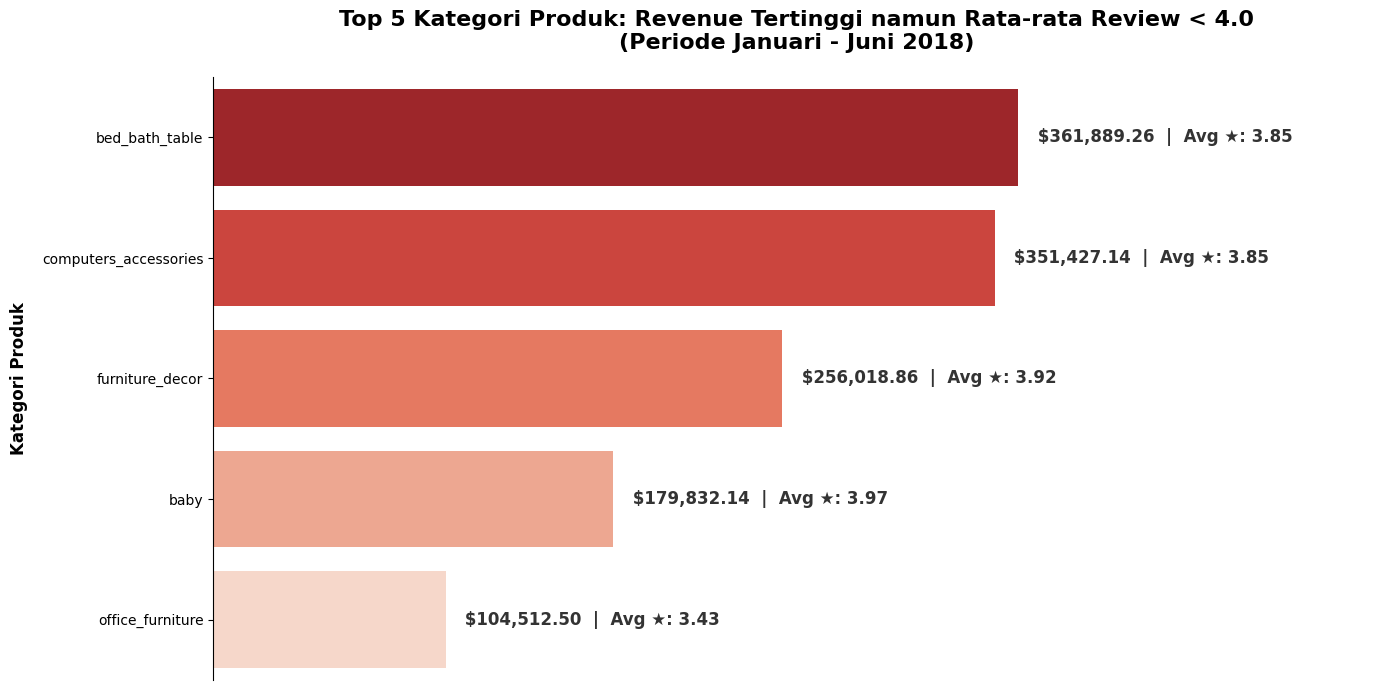

In [38]:
top_5_problematic = problematic_cats.head(5).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    x='total_revenue',
    y='product_category_name',
    data=top_5_problematic,
    palette='Reds_r',
    hue='product_category_name',
    legend=False,
    ax=ax
)

ax.set_title('Top 5 Kategori Produk: Revenue Tertinggi namun Rata-rata Review < 4.0\n(Periode Januari - Juni 2018)',
             fontsize=16, pad=20, fontweight='bold')

# Menyembunyikan sumbu X
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Kategori Produk', fontsize=12, fontweight='bold', labelpad=10)

sns.despine(bottom=True, right=True, top=True)

for i, p in enumerate(ax.patches):
    revenue_val = p.get_width()
    avg_rev = top_5_problematic['avg_review_score'].iloc[i]

    ax.annotate(
        f' ${revenue_val:,.2f}  |  Avg ★: {avg_rev:.2f}',
        (revenue_val, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(10, 0),
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

ax.set_xlim(0, top_5_problematic['total_revenue'].max() * 1.45)

plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:**


Berdasarkan analisis performa seller yang menangani produk dengan berat lebih dari 7kg di wilayah Sao Paulo, 10 seller terbaik yang memenuhi kriteria rata-rata skor review di atas 4.0. Seperti yang terlihat pada visualisasi pertanyaan 1, daftar teratas seller tersebut didominasi oleh seller dengan ID **3d871de0142ce09b7081e2b9d1733cb1** yang berhasil menangani **279 pesanan**, diikuti oleh seller ID **37be5a7c751166fbc5f8ccba4119e043** dengan **150 pesanan**, dan seterusnya. Kesepuluh seller ini membuktikan kemampuannya mempertahankan kepuasan pelanggan yang sangat tinggi meskipun menangani logistik produk yang kompleks dan berat.

- **Conclusion pertanyaan 2:**

Analisis tren keterlambatan pengiriman di Sao Paulo selama periode Januari-Juni 2018 seperti yang terlihat pada visualisasi pertama menunjukkan adanya dinamika performa yang signifikan pada bulan **Mei 2018** yang dirasakan pelanggan di wilayah ini dengan rata-rata keterlambatan pengiriman sebesar **39.2 hari**. Tapi, pada bulan selanjutnya, tren ini mulai membaik. Meskipun begitu, visualisasi ke-dua mengidentifikasi bahwa kategori **consoles_games** memiliki performa terburuk dengan rata-rata keterlambatan tertinggi sebesar **43.4 hari**.

- **Conclusion Pertanyaan 3:**

Melalui analisis periode Januari-Juni 2018 yang berfokus pada anomali performa seperti pada visualisasi di atas, ditemukan bahwa kategori produk yang memiliki total revenue tertinggi namun dengan rata-rata skor review di bawah 4.0 adalah kategori **bed_bath_table**. Kategori ini menghasilkan total revenue yang sangat signifikan, yaitu sebesar **\$361,889.26** , namun hanya mendapatkan rata-rata kepuasan pelanggan sebesar **3.85**. Selain itu, kategori **computers_accessories** juga perlu diwaspadai dengan revenue **\$351,427.14** dan rating **3.85**

**Rekomendasi Action Item:**

**Rekomendasi untuk pertanyaan 1**
- **Pemberdayaan Seller Spesialis Barang Berat:**
Platform sebaiknya memberikan insentif atau komisi khusus kepada 10 seller berkinerja tinggi yang sudah teridentifikasi untuk memastikan mereka tetap setia menggunakan platform.

- **Standardisasi Operasional:** Menggunakan proses operasional dari seller-seller terbaik ini sebagai benchmark atau panduan bagi seller baru yang ingin menjual produk kategori berat agar tetap bisa menjaga rating di atas 4.0.

**Rekomendasi untuk pertanyaan 2**
- **Audit Operasional Wilayah Sao Paulo:**
Manajemen logistik perlu melakukan investigasi mendalam terhadap gangguan yang terjadi pada Mei 2018 di Sao Paulo untuk mencegah kejadian serupa. Selain itu, perlu dilakukan evaluasi kontrak dengan mitra kurir yang menangani kategori produk dengan tingkat keterlambatan ekstrem seperti **consoles_games** dan **luggage_accessories**.

- **Penyesuaian Algoritma Estimasi Waktu (SLA):**
Memperbarui sistem estimasi tanggal kedatangan secara otomatis pada aplikasi untuk kategori yang rawan terlambat. Estimasi yang diberikan ke pelanggan di Sao Paulo sebaiknya ditambah buffer waktu agar pelanggan tidak kecewa.

**Rekomendasi untuk pertanyaan 3**
- **Peningkatan Quality Control (QC) Kategori Strategis:**
Untuk kategori produk dengan revenue tinggi dan rating rendah, platform harus mewajibkan vendor untuk melakukan QC yang lebih ketat. Tim konten juga perlu meninjau ulang akurasi deskripsi dan foto produk pada kategori tersebut untuk meminimalisir ekspektasi pelanggan yang salah.

- **Filtering Seller Berkualitas Rendah:** Memberikan peringatan atau sanksi bagi seller pada kategori **bed_bath_table** dan **computers_accessorires** yang secara konsisten memberikan produk berkualitas rendah, guna menyelamatkan reputasi platform dan mempertahankan revenue tinggi dari kategori tertentu dalam jangka panjang.